## $C_\ell^I$ and $C_\ell^V$ upper limit analysis — linear (spherical-harmonics) basis

Computes 95% upper limits on the angular power spectra of **intensity** ($C_\ell^I$)
and **circular polarization** ($C_\ell^V$) anisotropies of the GWB using the
Fisher-matrix formalism and the **doubled-real formulation** for the I+V likelihood.

Key points:
- Covariance: $M = \tfrac12\bigl[\begin{smallmatrix}R&-A\\A&R\end{smallmatrix}\bigr]$,
  with $R$ = I-mode signal + noise, $A$ = V-mode signal.
- Angular structure expanded in real $Y_{\ell m}$ up to $\ell_{\rm max}$.
- $I$-mode monopole ($c^I_{00}$) is excluded (degenerate with spectral amplitude).
- $V$-mode monopole vanishes by symmetry and is excluded.
- At fiducial $V=0$ the Fisher is block-diagonal: $F^{IV}=0$ (parity argument),
  so $C_\ell^I$ and $C_\ell^V$ limits are computed independently from each block.
- $C_\ell^I$ results are compared with NANOGrav 15-yr limits;
  $C_\ell^V$ results are compared with prior-only limits.

In [1]:
# Global
import os
import sys
import time
import tqdm
import numpy as np
import matplotlib.pyplot as plt

# Local
import fastPTA.utils as ut
from fastPTA.signals import get_signal_model
from fastPTA.Fisher_code import compute_fisher
from fastPTA.angular_decomposition import spherical_harmonics as sph

sys.path.insert(0, os.path.abspath("../"))

# Create output directories
for _dir in ["generated_data", "plots"]:
    os.makedirs(_dir, exist_ok=True)

# Load EPTAlike pulsar noise configuration
EPTAlike = ut.load_yaml("../pulsar_configurations/EPTAlike_pulsar_parameters.yaml")

### Configuration

In [2]:
# Total observation time in years
T_obs_yrs = 16.03

# Number of frequency bins
n_frequencies = 30

# Number of pulsars in the mock catalog
n_pulsars = 68

# Maximum multipole for the angular decomposition
l_max = 6

# Signal model
signal_model = get_signal_model("power_law")

# Fiducial spectral parameters: log10(amplitude) and tilt
log_amplitude = -7.1995
tilt = 2.0

# Number of catalog realizations for the ensemble analysis
N_realizations = 30

# Set True to force regeneration even if saved data exists
regenerate_fisher_data = False
regenerate_sample_data = False

# Output name (files saved in generated_data/)
outname = "NGlike_IV" 

### Sampling and plot settings

In [3]:
# Confidence level for upper limits
limit_cl = 0.95

# Posterior samples per realization
n_points = int(1e4)

# Realizations to include in the plot
N_realizations_in_plot = 30

### Build the fiducial injection

In [4]:
# Total real spherical harmonics coefficients up to l_max: (l_max+1)^2
n_lm = sph.get_n_coefficients_real(l_max)

# V-mode: monopole excluded, so n_lm - 1 free parameters
n_lm_V = n_lm - 1

# I-mode lm: isotropic monopole, all higher multipoles zero
signal_lm = 1e-30 / np.sqrt(4 * np.pi) * np.ones(n_lm)
signal_lm[0] = 1.0 / np.sqrt(4 * np.pi)   # normalised isotropic monopole

# V-mode lm: fiducial V = 0 everywhere
signal_lm_V = np.zeros(n_lm_V)

# Spectral parameters
signal_parameters = np.array([log_amplitude, tilt])
shape_params = len(signal_parameters)  # = 2

# Parameter ordering in the raw Fisher (HD_order=0 -> no HD parameters):
#   [log_amp(0), tilt(1), c^I_00(2/monopole), c^I_10(3), ..., c^V_10, ...]
# After removing the I-mode monopole at index shape_params = 2:
#   [log_amp, tilt, c^I_10, ..., c^V_10, ...]

# Means for the I-mode block (spectral + free I-mode lm)
means_I = np.concatenate((signal_parameters, signal_lm[1:]))

# Means for the V-mode block (V-mode lm only, all zero at fiducial)
means_V = signal_lm_V

# Full mean vector (for reference)
means = np.concatenate((means_I, means_V))

print(f"l_max = {l_max}")
print(f"Total I-mode lm:       {n_lm}  (monopole fixed, {n_lm_V} free)")
print(f"Total V-mode lm:       {n_lm_V}  (monopole excluded)")
print(f"Spectral parameters:   {shape_params}")
print(f"Total free parameters: {len(means)}")

l_max = 6
Total I-mode lm:       49  (monopole fixed, 48 free)
Total V-mode lm:       48  (monopole excluded)
Spectral parameters:   2
Total free parameters: 98


### Define inputs for `compute_fisher`

In [5]:
# Kwargs for generating pulsar catalogs (NANOGrav positions, EPTA-like noise)
generate_catalog_kwargs = {
    "n_pulsars": n_pulsars,
    "save_catalog": True,
    "use_ng_positions": True,
    **EPTAlike,
}

# Kwargs for get_tensors:
#   anisotropies=True  -> compute anisotropic response tensors
#   circ_pol=True      -> compute V-mode response tensor (doubles real formulation)
#   l_max              -> maximum multipole
get_tensors_kwargs = {
    "path_to_pulsar_catalog": "../pulsar_configurations/EPTA68.txt",
    "add_curn": False,
    "regenerate_catalog": True,
    "anisotropies": True,
    "circ_pol": True,
    "l_max": l_max,
}

# Kwargs for compute_fisher:
#   signal_lm_V -> activates doubled-real I+V formulation
fisher_kwargs = {
    "T_obs_yrs": T_obs_yrs,
    "n_frequencies": n_frequencies,
    "signal_model": signal_model,
    "signal_parameters": signal_parameters,
    "signal_lm": signal_lm,
    "signal_lm_V": signal_lm_V,
}

### Generate Fisher matrices

For each of the `N_realizations` catalog realizations we compute the full Fisher
matrix and then extract the two block-diagonal pieces.

At the fiducial $V=0$ the Fisher is exactly block-diagonal (parity argument):
$$F = \begin{pmatrix} F^{II} & 0 \\ 0 & F^{VV} \end{pmatrix}$$
so saving and inverting each block independently is mathematically exact.

In [6]:
# I-mode monopole is at index shape_params = 2 in the raw Fisher
monopole_idx = shape_params  # = 2

# Block sizes after removing the monopole
n_I_block = shape_params + n_lm_V   # spectral + free I-mode lm
n_V_block = n_lm_V                   # V-mode lm

try:
    if regenerate_fisher_data:
        raise FileNotFoundError("Regeneration requested")

    saved = np.load("generated_data/" + outname + ".npz")
    fisher_I = saved["fisher_I"]
    fisher_V = saved["fisher_V"]
    print(f"Loaded Fisher matrices ({len(fisher_I)} realizations).")

except FileNotFoundError:
    fisher_I = np.zeros((N_realizations, n_I_block, n_I_block))
    fisher_V = np.zeros((N_realizations, n_V_block, n_V_block))

    for index in tqdm.tqdm(range(N_realizations)):
        res = np.array(compute_fisher(
            **fisher_kwargs,
            get_tensors_kwargs=get_tensors_kwargs,
            generate_catalog_kwargs=generate_catalog_kwargs,
        )[-1])

        # Remove I-mode monopole (degenerate with spectral amplitude)
        res_red = np.delete(np.delete(res, monopole_idx, axis=0), monopole_idx, axis=1)

        # Extract block-diagonal pieces (exact at fiducial V=0)
        fisher_I[index] = res_red[:n_I_block, :n_I_block]
        fisher_V[index] = res_red[n_I_block:, n_I_block:]

    np.savez(
        "generated_data/" + outname + ".npz",
        fisher_I=fisher_I,
        fisher_V=fisher_V,
    )
    print(f"Generated and saved Fisher matrices ({N_realizations} realizations).")

print(f"I-mode Fisher block shape: {fisher_I.shape}")
print(f"V-mode Fisher block shape: {fisher_V.shape}")

Loaded Fisher matrices (30 realizations).
I-mode Fisher block shape: (30, 50, 50)
V-mode Fisher block shape: (30, 48, 48)


### Compute $C_\ell^I$ upper limits

Invert the I-mode Fisher block, sample from the posterior, and compute 95% upper
limits using `sph.get_Cl_limits`.

The tilt parameter acts as a dummy monopole placeholder inside `get_Cl_limits`
(taking `data.T[shape_params-1:]` = `[tilt, c^I_{10}, ...]` and calling
`get_CL_from_real_clm` which returns $C_\ell$ for $\ell \geq 0$; the $\ell=0$
entry—corresponding to the tilt—is then discarded with `[1:]`).

In [7]:
# Invert the I-mode Fisher block for each realization
cov_I = ut.compute_inverse(fisher_I)  # shape (N_realizations, n_I_block, n_I_block)

n_plot = min(N_realizations_in_plot, N_realizations)

def get_Cl_I_wrapper(params):
    return sph.get_Cl_limits(
        *params,
        shape_params,
        n_points=n_points,
        limit_cl=limit_cl,
        max_iter=100,
        prior=5.0 / (4.0 * np.pi),
    )

arg_grid_I = [[means_I, cov_I[j]] for j in range(n_plot)]

try:
    if regenerate_sample_data:
        raise FileNotFoundError("Regeneration requested")
    Cl_limits_I = np.loadtxt("generated_data/Cl_limits_I_" + outname + ".dat")
    Cl_limits_I_prior = np.loadtxt(
        "generated_data/Cl_limits_I_prior_" + outname + ".dat"
    )
    if len(Cl_limits_I) != n_plot:
        raise FileNotFoundError("Wrong number of realizations")
    print(f"Loaded Cl^I limits ({len(Cl_limits_I)} realizations).")

except FileNotFoundError:
    start = time.time()
    res_I = []
    for params in tqdm.tqdm(arg_grid_I):
        res_I.append(get_Cl_I_wrapper(params))
    res_I = np.array(res_I)
    print(f"Cl^I limits computed in {time.time() - start:.1f}s")

    Cl_limits_I = res_I[:, 0] * 4 * np.pi
    Cl_limits_I_prior = res_I[:, 1] * 4 * np.pi

    np.savetxt("generated_data/Cl_limits_I_" + outname + ".dat", Cl_limits_I)
    np.savetxt("generated_data/Cl_limits_I_prior_" + outname + ".dat", Cl_limits_I_prior)
    print("  Saved Cl^I limits.")

Loaded Cl^I limits (30 realizations).


### Compute $C_\ell^V$ upper limits

For the V-mode block there is no spectral parameter to act as a dummy monopole,
so we write a small helper that prepends a zero to each sample before calling
`sph.get_CL_from_real_clm`, then discards the $\ell=0$ result.

In [8]:
def get_Cl_V_limits(means_V, cov_V, n_points, limit_cl, prior, max_iter=100):
    # Sample from the V-mode posterior
    data = np.random.multivariate_normal(
        means_V, cov_V, n_points, check_valid="ignore", tol=1e-4
    )
    # Apply flat prior: keep samples with all |c^V_lm| <= prior
    data_prior = data[np.max(np.abs(data), axis=-1) <= prior]
    i_add = 0
    while len(data_prior) < n_points and i_add < max_iter:
        extra = np.random.multivariate_normal(
            means_V, cov_V, 10 * n_points, check_valid="ignore", tol=1e-4
        )
        data_prior = np.vstack(
            [data_prior, extra[np.max(np.abs(extra), axis=-1) <= prior]]
        )
        i_add += 1

    # Prepend dummy zero monopole so get_CL_from_real_clm gets n_lm entries
    dummy = np.zeros((len(data), 1))
    Cl_V = sph.get_CL_from_real_clm(np.hstack([dummy, data]).T)[1:]

    if len(data_prior) == 0:
        Cl_V_prior = np.full(len(Cl_V), np.nan)
    else:
        dummy_p = np.zeros((len(data_prior), 1))
        Cl_V_prior = sph.get_CL_from_real_clm(
            np.hstack([dummy_p, data_prior]).T
        )[1:]
        Cl_V_prior = np.quantile(Cl_V_prior, limit_cl, axis=-1)

    return np.quantile(Cl_V, limit_cl, axis=-1), Cl_V_prior


# Invert V-mode Fisher block for each realization
cov_V = ut.compute_inverse(fisher_V)  # shape (N_realizations, n_lm_V, n_lm_V)

try:
    if regenerate_sample_data:
        raise FileNotFoundError("Regeneration requested")
    Cl_limits_V = np.loadtxt("generated_data/Cl_limits_V_" + outname + ".dat")
    Cl_limits_V_prior = np.loadtxt(
        "generated_data/Cl_limits_V_prior_" + outname + ".dat"
    )
    if len(Cl_limits_V) != n_plot:
        raise FileNotFoundError("Wrong number of realizations")
    print(f"Loaded Cl^V limits ({len(Cl_limits_V)} realizations).")

except FileNotFoundError:
    start = time.time()
    Cl_V_list, Cl_V_prior_list = [], []
    for j in tqdm.tqdm(range(n_plot)):
        cl_v, cl_v_prior = get_Cl_V_limits(
            means_V, cov_V[j], n_points, limit_cl, prior=5.0 / (4.0 * np.pi)
        )
        Cl_V_list.append(cl_v * 4 * np.pi)
        Cl_V_prior_list.append(cl_v_prior * 4 * np.pi)

    Cl_limits_V = np.array(Cl_V_list)
    Cl_limits_V_prior = np.array(Cl_V_prior_list)
    print(f"Cl^V limits computed in {time.time() - start:.1f}s")

    np.savetxt("generated_data/Cl_limits_V_" + outname + ".dat", Cl_limits_V)
    np.savetxt("generated_data/Cl_limits_V_prior_" + outname + ".dat", Cl_limits_V_prior)
    print("  Saved Cl^V limits.")

Loaded Cl^V limits (30 realizations).


### Prior-only upper limits

In [9]:
# --- Prior-only C_l^I ---
# Sample from the flat prior; tilt acts as dummy monopole (same trick as get_Cl_limits)
data_prior_I = np.random.uniform(
    -5.0 / (4.0 * np.pi), 5.0 / (4.0 * np.pi),
    (n_points, len(means_I) - 1),  # = 1 (tilt) + n_lm_V = n_lm coefficients
)
Cl_I_prior_values = sph.get_CL_from_real_clm(data_prior_I.T)[1:]
Cl_prior_I = np.quantile(Cl_I_prior_values, limit_cl, axis=-1) * 4 * np.pi

# --- Prior-only C_l^V ---
# Sample V-mode lm from prior, prepend zero monopole
data_prior_V = np.random.uniform(
    -5.0 / (4.0 * np.pi), 5.0 / (4.0 * np.pi),
    (n_points, n_lm_V),
)
dummy_zero = np.zeros((n_points, 1))
Cl_V_prior_values = sph.get_CL_from_real_clm(
    np.hstack([dummy_zero, data_prior_V]).T
)[1:]
Cl_prior_V = np.quantile(Cl_V_prior_values, limit_cl, axis=-1) * 4 * np.pi

ell = np.arange(1, l_max + 1)
print("Prior-only C_l^I / C_0:", Cl_prior_I)
print("Prior-only C_l^V / C_0:", Cl_prior_V)

Prior-only C_l^I / C_0: [1.27553594 1.12565196 1.05469571 0.99629936 0.97073606 0.94258054]
Prior-only C_l^V / C_0: [1.26775061 1.12928799 1.04810942 1.00084828 0.96884945 0.94220729]


### Compute ensemble statistics

In [10]:
# Load NANOGrav 15-yr intensity limits for comparison with Cl^I
limits_NG = np.loadtxt(
    "../examples_paper_anisotropies/data_paper_2/limits_Cl_powerlaw_lin_ng15.dat"
)[:, 1]

# --- C_l^I ensemble statistics ---
mean_Cl_I = np.mean(Cl_limits_I, axis=0)
err_low_Cl_I  = mean_Cl_I - np.quantile(Cl_limits_I, 0.025, axis=0)
err_high_Cl_I = np.quantile(Cl_limits_I, 0.975, axis=0) - mean_Cl_I

valid_I = np.isfinite(Cl_limits_I_prior).all(axis=1)
if valid_I.any():
    mean_Cl_I_prior     = np.mean(Cl_limits_I_prior[valid_I], axis=0)
    err_low_Cl_I_prior  = mean_Cl_I_prior - np.quantile(Cl_limits_I_prior[valid_I], 0.025, axis=0)
    err_high_Cl_I_prior = np.quantile(Cl_limits_I_prior[valid_I], 0.975, axis=0) - mean_Cl_I_prior
else:
    print("Warning: no finite Cl^I prior-constrained realizations.")
    mean_Cl_I_prior     = np.full(l_max, np.nan)
    err_low_Cl_I_prior  = np.full(l_max, np.nan)
    err_high_Cl_I_prior = np.full(l_max, np.nan)

# --- C_l^V ensemble statistics ---
mean_Cl_V = np.mean(Cl_limits_V, axis=0)
err_low_Cl_V  = mean_Cl_V - np.quantile(Cl_limits_V, 0.025, axis=0)
err_high_Cl_V = np.quantile(Cl_limits_V, 0.975, axis=0) - mean_Cl_V

valid_V = np.isfinite(Cl_limits_V_prior).all(axis=1)
if valid_V.any():
    mean_Cl_V_prior     = np.mean(Cl_limits_V_prior[valid_V], axis=0)
    err_low_Cl_V_prior  = mean_Cl_V_prior - np.quantile(Cl_limits_V_prior[valid_V], 0.025, axis=0)
    err_high_Cl_V_prior = np.quantile(Cl_limits_V_prior[valid_V], 0.975, axis=0) - mean_Cl_V_prior
else:
    print("Warning: no finite Cl^V prior-constrained realizations.")
    mean_Cl_V_prior     = np.full(l_max, np.nan)
    err_low_Cl_V_prior  = np.full(l_max, np.nan)
    err_high_Cl_V_prior = np.full(l_max, np.nan)

print(f"Mean C_l^I limits (l=1..{l_max}): {mean_Cl_I}")
print(f"Mean C_l^V limits (l=1..{l_max}): {mean_Cl_V}")
print(f"Valid Cl^I prior realizations: {valid_I.sum()} / {len(valid_I)}")
print(f"Valid Cl^V prior realizations: {valid_V.sum()} / {len(valid_V)}")

Mean C_l^I limits (l=1..6): [ 0.31839821  1.04024989  2.50094699  5.24979468  8.53847529 10.18808202]
Mean C_l^V limits (l=1..6): [  6.97435851  12.89185653  29.45168489  58.88961632  93.15704558
 100.55430902]
Valid Cl^I prior realizations: 15 / 30
Valid Cl^V prior realizations: 0 / 30


### Plot results

[nan nan nan nan nan nan]


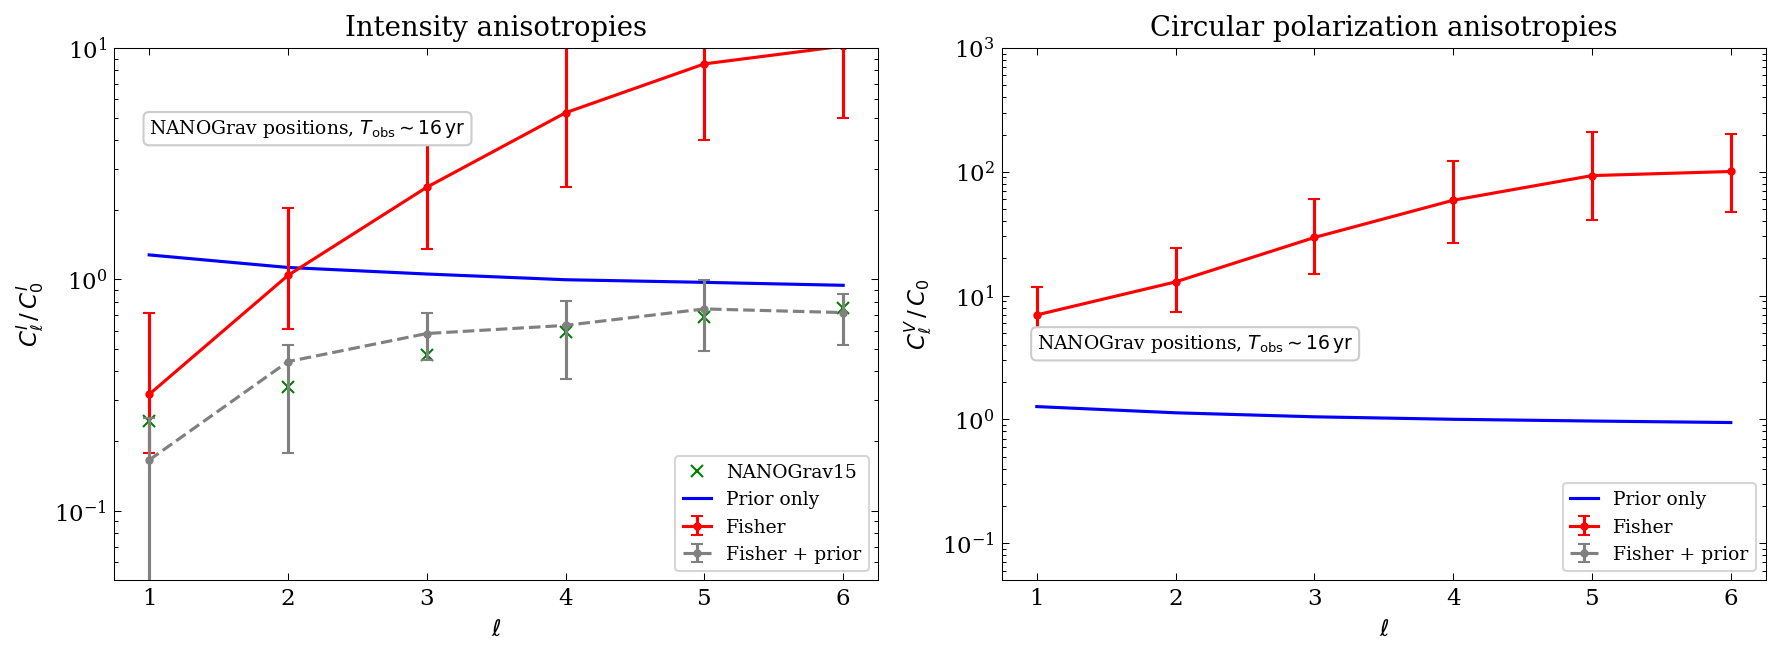

In [11]:
plt.rc("text", usetex=False)
plt.rc("font", family="serif", size=11)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150)
box_props = dict(boxstyle="round", facecolor="white", alpha=1, linewidth=1, edgecolor="0.8")

# ── Left: C_l^I ──────────────────────────────────────────────────────────────
ax = axes[0]
ax.tick_params(axis="both", which="both", labelsize=11, direction="in", width=0.5)
ax.xaxis.set_ticks_position("both")
ax.yaxis.set_ticks_position("both")
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

ax.semilogy(ell, limits_NG, label="NANOGrav15", color="green", marker="x", lw=0)
ax.semilogy(ell, Cl_prior_I, color="blue", label="Prior only")
ax.errorbar(
    ell, mean_Cl_I, yerr=(err_low_Cl_I, err_high_Cl_I),
    color="red", label="Fisher", marker=".", capsize=3,
)
ax.errorbar(
    ell, mean_Cl_I_prior, yerr=(err_low_Cl_I_prior, err_high_Cl_I_prior),
    color="grey", label="Fisher + prior", marker=".", capsize=3, ls="--",
)
ax.text(
    1, 5.0,
    r"NANOGrav positions, $T_{\mathrm{obs}} \sim 16\,\mathrm{yr}$",
    ha="left", fontsize=9, va="top", bbox=box_props, linespacing=1.4,
)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$C_\ell^I \,/\, C_0^I$")
ax.set_title(r"Intensity anisotropies")
ax.legend(loc="lower right", fontsize=9, handlelength=1.5)
ax.set_ylim(5e-2, 10)

# ── Right: C_l^V ─────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.tick_params(axis="both", which="both", labelsize=11, direction="in", width=0.5)
ax2.xaxis.set_ticks_position("both")
ax2.yaxis.set_ticks_position("both")
for spine in ax2.spines.values():
    spine.set_linewidth(0.5)

ax2.semilogy(ell, Cl_prior_V, color="blue", label="Prior only")
ax2.errorbar(
    ell, mean_Cl_V, yerr=(err_low_Cl_V, err_high_Cl_V),
    color="red", label="Fisher", marker=".", capsize=3,
)
ax2.errorbar(
    ell, 1 + mean_Cl_V_prior, yerr=(err_low_Cl_V_prior, err_high_Cl_V_prior),
    color="grey", label="Fisher + prior", marker=".", capsize=3, ls="--",
)
print(mean_Cl_V_prior)
ax2.text(
    1, 5.0,
    r"NANOGrav positions, $T_{\mathrm{obs}} \sim 16\,\mathrm{yr}$",
    ha="left", fontsize=9, va="top", bbox=box_props, linespacing=1.4,
)
ax2.set_xlabel(r"$\ell$")
ax2.set_ylabel(r"$C_\ell^V \,/\, C_0$")
ax2.set_title(r"Circular polarization anisotropies")
ax2.legend(loc="lower right", fontsize=9, handlelength=1.5)
ax2.set_ylim(5e-2, 1000)

plt.tight_layout()
plt.savefig("plots/Cl_sens_lim_IV_ng_like.pdf", bbox_inches="tight")
plt.show()

### Comparison: $C_\ell^I$ vs $C_\ell^V$ sensitivity

Show intensity and circular polarization Fisher limits on the same axes to
directly compare the sensitivity ratio $C_\ell^V / C_\ell^I$.

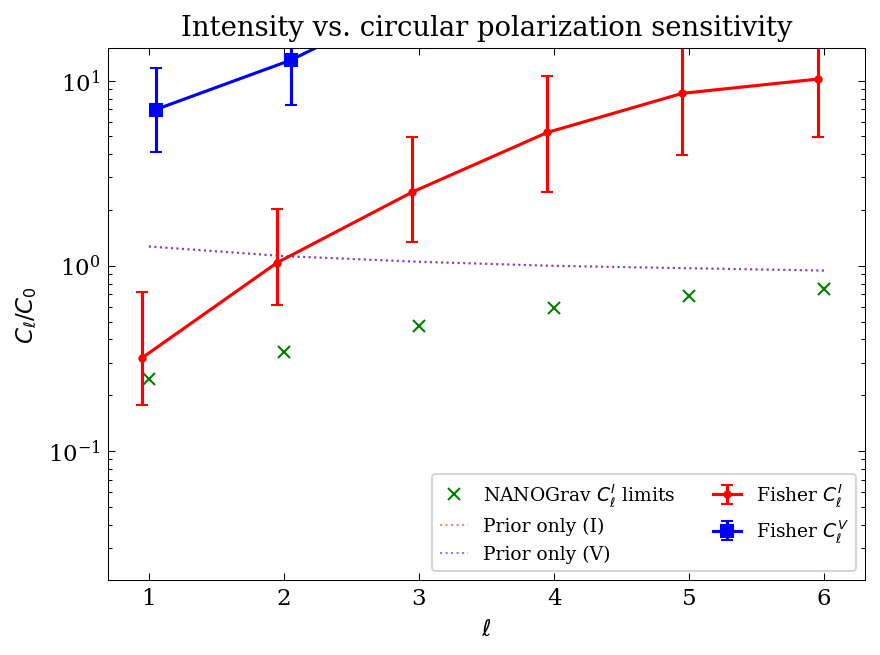

C_l^V / C_l^I sensitivity ratio:
  l=1: 21.90x
  l=2: 12.39x
  l=3: 11.78x
  l=4: 11.22x
  l=5: 10.91x
  l=6: 9.87x


In [12]:
fig, ax = plt.subplots(figsize=(6, 4.5), dpi=150)
ax.tick_params(axis="both", which="both", labelsize=11, direction="in", width=0.5)
ax.xaxis.set_ticks_position("both")
ax.yaxis.set_ticks_position("both")
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

ax.semilogy(ell, limits_NG, color="green", marker="x", lw=0, label="NANOGrav $C_\ell^I$ limits")
ax.semilogy(ell, Cl_prior_I, color="red",  lw=1, ls=":", alpha=0.5, label="Prior only (I)")
ax.semilogy(ell, Cl_prior_V, color="blue", lw=1, ls=":", alpha=0.5, label="Prior only (V)")
ax.errorbar(
    ell - 0.05, mean_Cl_I, yerr=(err_low_Cl_I, err_high_Cl_I),
    color="red",  label=r"Fisher $C_\ell^I$", marker=".", capsize=3,
)
ax.errorbar(
    ell + 0.05, mean_Cl_V, yerr=(err_low_Cl_V, err_high_Cl_V),
    color="blue", label=r"Fisher $C_\ell^V$", marker="s", capsize=3,
)

ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$C_\ell / C_0$")
ax.set_title(r"Intensity vs. circular polarization sensitivity")
ax.legend(loc="lower right", fontsize=9, handlelength=1.5, ncol=2)
ax.set_ylim(2e-2, 15)
plt.tight_layout()
plt.savefig("plots/Cl_comparison_IV_ng_like.pdf", bbox_inches="tight")
plt.show()

# Print sensitivity ratio
ratio = mean_Cl_V / mean_Cl_I
print("C_l^V / C_l^I sensitivity ratio:")
for l_val, r in zip(ell, ratio):
    print(f"  l={int(l_val)}: {r:.2f}x")